# Random Forest Hyperparameter Tuning

# Objective
Optimize the Random Forest model using cross-validation and hyperparameter 
search, then compare it with the baseline

## Import Libraries

In [1]:
import pandas as pd
import joblib

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

## Data Preperation

### Load Data

In [2]:
df = pd.read_csv("../data/processed/cleveland_clean.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


### Data Split

In [3]:
X = df.drop(columns="target")

y = df["target"]

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)

### Preprocessin Pipeline

In [4]:
# Numerical pipeline
numerical_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# Categorical pipeline - leave them as they are, as they are already int-coded
categorical_pipeline = "passthrough"


# Combination
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

### Training

In [6]:
results = []

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

baseline_pipeline.fit(X_train,y_train)
    
y_pred = baseline_pipeline.predict(X_test)

y_prob = baseline_pipeline.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test,y_prob)
    
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)
    
results.append({
    "Model": "Random Forest Model",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
    })
    

In [7]:
result_df = pd.DataFrame(results)
result_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest Model,0.918033,0.870968,0.964286,0.915254,0.954004


## Hyperparameter Tuning

In [8]:
param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],

    "model__max_depth": [
        None,
        5,
        10,
        15,
        20
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "model__max_features": [
        "sqrt",
        "log2",
        None
    ]
}

### Randomized Search

In [9]:
search = RandomizedSearchCV(
    estimator=baseline_pipeline,

    param_distributions=param_distributions,

    n_iter=25,

    cv=5,

    scoring="f1",

    random_state=42,

    n_jobs=-1
)

### Fit the search

In [10]:
search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``Rando

### Best Parameters

In [11]:
search.best_params_

{'model__n_estimators': 100,
 'model__min_samples_split': 10,
 'model__min_samples_leaf': 2,
 'model__max_features': 'log2',
 'model__max_depth': 10}

In [12]:
search.best_score_

np.float64(0.7932376925400182)

### Evaluate the Best Model

In [13]:
best_pipeline = search.best_estimator_

In [18]:
tuned_results = []

y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]



roc_auc = roc_auc_score(y_test,y_prob)
    
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)
    
tuned_results.append({
    "Model": "Random Forest Model",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
    })
    


In [19]:
tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest Model,0.885246,0.83871,0.928571,0.881356,0.964286


In [15]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



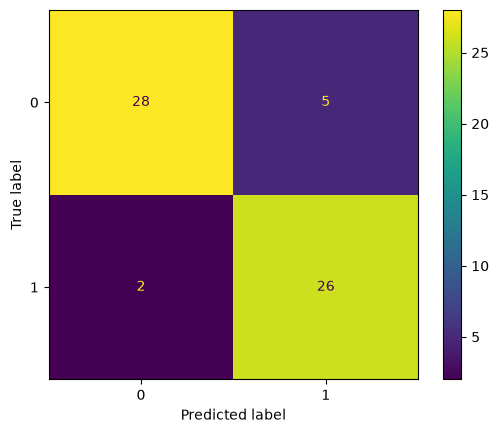

In [16]:
ConfusionMatrixDisplay.from_estimator(
    best_pipeline,
    X_test,
    y_test
)

| Metric    | Baseline | Tuned |
| --------- | -------: | ----: |
| Accuracy  |  0.91    |0.88    |
| Precision |  0.87    |0.83    |
| Recall    |  0.96    |0.92    |
| F1        |  0.91    |0.88    |
| ROC-AUC   |  0.95    |0.96    |



Interpretation
- Accuracy decrease 0.91 to 0.88 
- Precision decrease 0.87 to 0.83 
- Recall decrease 0.96 to 0.82 
- F1-Score decrease 0.91 to 0.88 
- ROC-AUC improved slightly from 0.95 to 0.96, suggesting model has better ability to distinguish between two classes at different threshold



Our tuned model did improved slightly in ROC-AUC, but the baseline model achieves higher accuracy, precision, recall and F1-Score. Unless we only care about the ROC-AUC as prime objective, The baseline model is better based on evaluation metrics

## Save the best Mode

In [23]:
joblib.dump(
    baseline_pipeline,
    "../models/random_forest_best.pkl"
)

['../models/random_forest_best.pkl']

## Hyperparameter Tuning Summary

- Radnom Forest was selected as the strongest baseline Model
- - RandomizedSearchCV with 5-fold cross-validation was used to optimize hyperparameters.
- The tuned model was evaluated on the held-out test set.
- Performance was compared against the baseline using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
- And baseline model was better with tuned model so it has been saved for deployment in next phase